## Import python libraries and download cleaned dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import sys

from pathlib import Path
sys.path.append(os.path.abspath(".."))

from util import *
import matplotlib.pyplot as plt

# Đọc luôn file dữ liệu SẠCH từ thư mục processed của bạn nhóm
# Dùng đường dẫn tương đối này thì ai trong nhóm mở máy lên cũng chạy được
df = pd.read_csv("../datasets/processed/cleaned_spotify_2023.csv")

# Xem qua các thông số trung bình, lớn nhất, nhỏ nhất
df[["danceability_%", "energy_%", "streams", "log_streams"]].describe()

,danceability_%,energy_%,streams,log_streams
count,952.000000,952.000000,9.520000e+02,952.000000
mean,66.984244,64.274160,5.141374e+08,19.506648
std,14.631282,16.558517,5.668569e+08,1.146289
min,23.000000,9.000000,2.762000e+03,7.924072
25%,57.000000,53.000000,1.416362e+08,18.768772
50%,69.000000,66.000000,2.905309e+08,19.487220
75%,78.000000,77.000000,6.738690e+08,20.328546
max,96.000000,97.000000,3.703895e+09,22.032651


## 1. Phân tích đơn biến (Univariate Analysis)
### a. Trực quan hóa phân phối của biến mục tiêu (`streams` và `log_streams`) bằng Histogram để đánh giá độ lệch.

Saving figure distribution_streams_plot


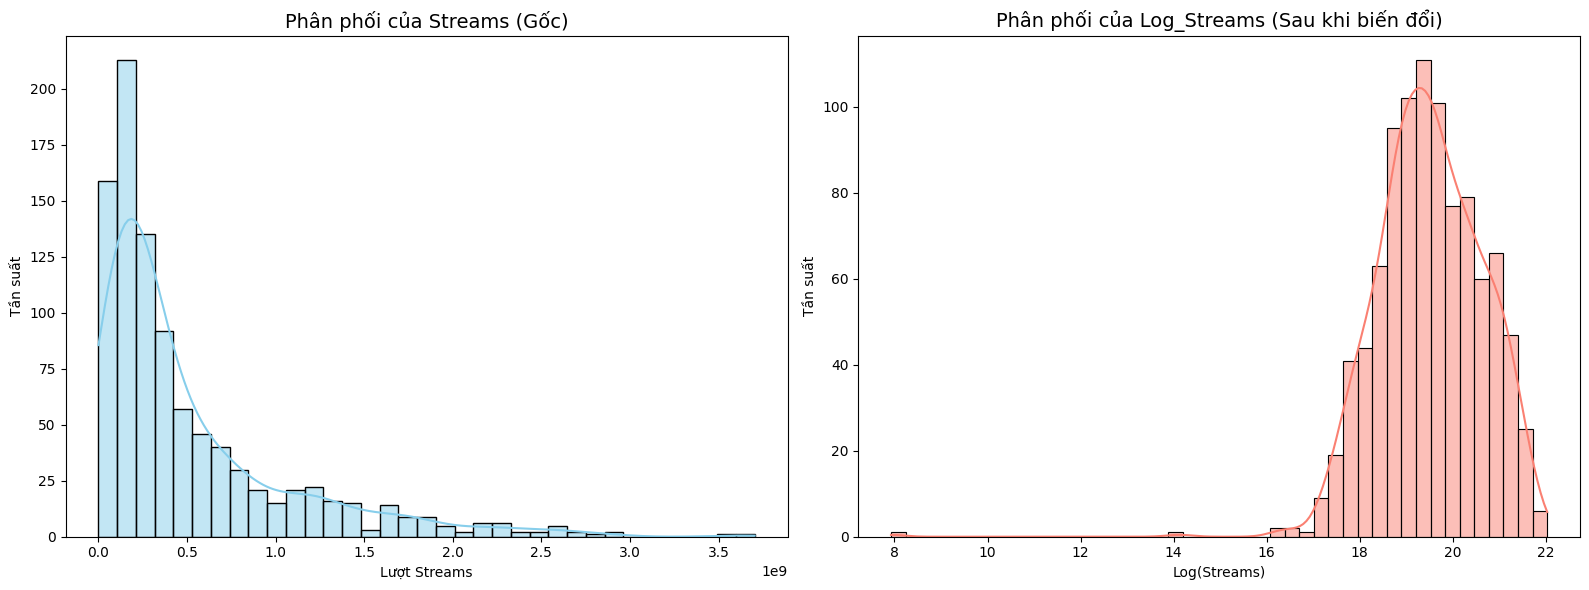

Độ lệch (Skewness) của Streams: 2.00
Độ lệch (Skewness) của Log_Streams: -1.19
→ Streams lệch phải mạnh: nên dùng log_streams làm biến mục tiêu khi mô hình hóa (OLS).
→ Log_streams gần đối xứng hơn streams gốc, phù hợp hơn cho giả định phân phối chuẩn của sai số.
→ Lưu ý: |skew| của log_streams vẫn ≈ 1.19; kiểm tra Q-Q plot trước khi kết luận phân phối chuẩn.


In [ ]:
# Chuẩn bị dữ liệu: Tạo cột log_streams nếu chưa có
# ln(1 + x) giúp tránh lỗi nếu streams bằng 0
if 'log_streams' not in df.columns:
    df['log_streams'] = np.log1p(df['streams'])

# Thiết lập khung vẽ (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Phân phối của 'streams'
sns.histplot(df['streams'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Phân phối của Streams (Gốc)', fontsize=14)
axes[0].set_xlabel('Lượt Streams')
axes[0].set_ylabel('Tần suất')

# Biểu đồ 2: Phân phối của 'log_streams'
sns.histplot(df['log_streams'], kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Phân phối của Log_Streams (Sau khi biến đổi)', fontsize=14)
axes[1].set_xlabel('Log(Streams)')
axes[1].set_ylabel('Tần suất')

# Hiển thị biểu đồ
plt.tight_layout()
# Lưu ảnh vào thư mục reports/figures
save_fig("distribution_streams_plot")
plt.show()

# In ra các chỉ số thống kê để đánh giá độ lệch (Skewness)
skew_raw = df['streams'].skew()
skew_log = df['log_streams'].skew()
print(f"Độ lệch (Skewness) của Streams: {skew_raw:.2f}")
print(f"Độ lệch (Skewness) của Log_Streams: {skew_log:.2f}")

if abs(skew_raw) > 1:
    print("→ Streams lệch phải mạnh: nên dùng log_streams làm biến mục tiêu khi mô hình hóa (OLS).")
if abs(skew_log) < abs(skew_raw):
    print("→ Log_streams gần đối xứng hơn streams gốc, phù hợp hơn cho giả định phân phối chuẩn của sai số.")
if abs(skew_log) >= 0.5:
    print(f"→ Lưu ý: |skew| của log_streams vẫn ≈ {abs(skew_log):.2f}; kiểm tra Q-Q plot trước khi kết luận phân phối chuẩn.")

### b. Sử dụng Boxplot để xác định các bài hát "siêu hit" (Outliers vượt trội trên thị trường).

Saving figure super_hits_boxplot


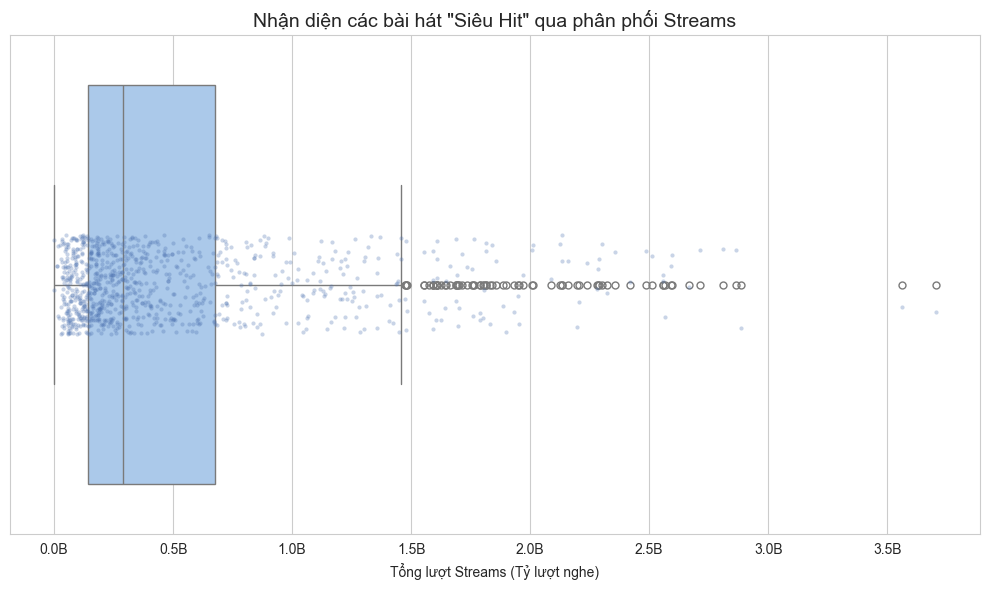

--- Ngưỡng xác định siêu hit (Outlier Threshold): 1472.22 triệu streams ---
Số lượng bài hát được coi là siêu hit: 74

Top 10 bài hát có lượt stream cao nhất:
                                        track_name  \
55                                 Blinding Lights   
179                                   Shape of You   
86                               Someone You Loved   
619                                   Dance Monkey   
41   Sunflower - Spider-Man: Into the Spider-Verse   
162                                      One Dance   
84                       STAY (with Justin Bieber)   
140                                       Believer   
724                                         Closer   
48                                         Starboy   

                   artist(s)_name     streams  
55                     The Weeknd  3703895074  
179                    Ed Sheeran  3562543890  
86                  Lewis Capaldi  2887241814  
619                   Tones and I  2864791672  
41    

In [ ]:
# Thiết lập kích thước và phong cách biểu đồ
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Vẽ Boxplot cho biến 'streams'
# Ta vẽ thêm 'stripplot' đè lên để thấy rõ từng điểm dữ liệu (từng bài hát)
ax = sns.boxplot(x=df['streams'], color='#A1C9F4', fliersize=5)
sns.stripplot(x=df['streams'], color='#4C72B0', alpha=0.3, size=3)

# Thêm tiêu đề và chú thích
plt.title('Nhận diện các bài hát "Siêu Hit" qua phân phối Streams', fontsize=14)
plt.xlabel('Tổng lượt Streams (Tỷ lượt nghe)')

# Tùy chỉnh hiển thị đơn vị trên trục X (chia cho 1 tỷ để dễ đọc)
from matplotlib.ticker import FuncFormatter

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x / 1e9:.1f}B'))

# Ảnh sẽ được lưu vào reports/figures/super_hits_boxplot.png
save_fig("super_hits_boxplot")
plt.show()

# Liệt kê top các bài hát là Outliers (Siêu hit)
# Theo quy tắc IQR, outliers là các điểm > Q3 + 1.5 * IQR
Q1 = df['streams'].quantile(0.25)
Q3 = df['streams'].quantile(0.75)
IQR = Q3 - Q1
threshold = Q3 + 1.5 * IQR

super_hits = df[df['streams'] > threshold][['track_name', 'artist(s)_name', 'streams']].sort_values(by='streams', ascending=False)

print(f"--- Ngưỡng xác định siêu hit (Outlier Threshold): {threshold/1e6:.2f} triệu streams ---")
print(f"Số lượng bài hát được coi là siêu hit: {len(super_hits)}")
print("\nTop 10 bài hát có lượt stream cao nhất:")
print(super_hits.head(10))

### c. Thống kê mô tả xu hướng trung tâm (Mean, Median) của các đặc tính âm thanh kỹ thuật số.

--- Thống kê xu hướng trung tâm của các đặc tính âm thanh ---


,Mean,Median,Std Dev,Min,Max
danceability_%,66.98,69.0,14.63,23.0,96.0
energy_%,64.27,66.0,16.56,9.0,97.0
valence_%,51.41,51.0,23.48,4.0,97.0
acousticness_%,27.08,18.0,26.00,0.0,97.0
instrumentalness_%,1.58,0.0,8.41,0.0,91.0
liveness_%,18.21,12.0,13.72,3.0,97.0
speechiness_%,10.14,6.0,9.92,2.0,64.0


Saving figure audio_features_distribution


C:\Users\THIN BOX\AppData\Local\Temp\ipykernel_17588\4096951340.py:34: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


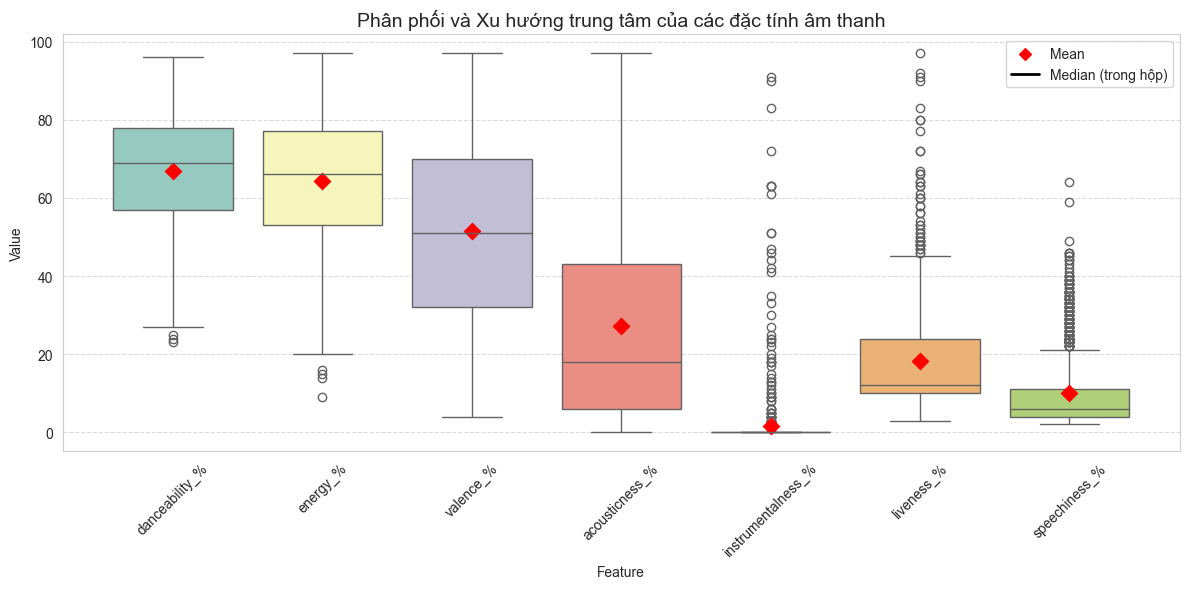

In [ ]:
# Danh sách các đặc tính âm thanh kỹ thuật số cần phân tích
audio_features = [
    'danceability_%', 'energy_%', 'valence_%', 
    'acousticness_%', 'instrumentalness_%', 
    'liveness_%', 'speechiness_%'
]

# Tính toán các chỉ số thống kê mô tả (Mean, Median, Std,...)
# Chúng ta dùng .agg để lấy đúng các giá trị cần thiết
descriptive_stats = df[audio_features].agg(['mean', 'median', 'std', 'min', 'max']).T
descriptive_stats.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max']

print("--- Thống kê xu hướng trung tâm của các đặc tính âm thanh ---")
display(descriptive_stats.round(2))

# Trực quan hóa để so sánh Mean và Median
plt.figure(figsize=(12, 6))

# Chuyển dữ liệu sang dạng long-format để vẽ biểu đồ dễ hơn
df_melted = df[audio_features].melt(var_name='Feature', value_name='Value')

# Vẽ boxplot để thấy Median và phân phối
sns.boxplot(
    data=df_melted,
    x='Feature',
    y='Value',
    hue='Feature',
    palette='Set3',
    legend=False,
    dodge=False
)

# Vẽ thêm các điểm Mean bằng màu đỏ để so sánh trực quan
sns.pointplot(
    data=df_melted,
    x='Feature',
    y='Value',
    estimator='mean',
    color='red',
    markers='D',
    join=False,
    errorbar=None
)

plt.title('Phân phối và Xu hướng trung tâm của các đặc tính âm thanh', fontsize=14)
plt.xticks(rotation=45)
plt.scatter([], [], c='red', marker='D', label='Mean')
plt.plot([], [], color='black', linewidth=2, label='Median (trong hộp)')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

# Ảnh sẽ được lưu vào reports/figures/audio_features_distribution.png
save_fig("audio_features_distribution")
plt.show()

## 2. Phân tích đặc tính âm nhạc và mức độ thành công (`log_streams` / Hit Status)
### a. Biểu đồ Scatter plot và đường xu hướng (Trendline):
* `danceability_%` tác động thế nào đến `log_streams`?
* `energy_%` tác động thế nào đến `log_streams`?
* Màu sắc điểm: **Hit** (streams ≥ Q3) vs **Không hit** — nhãn phụ cho phân tích Hit Status.

--- Hit Status: ngưỡng Q3 = 673.87 triệu streams (238 bài hit / 952 bài) ---
Saving figure scatter_danceability_energy_logstreams_trends


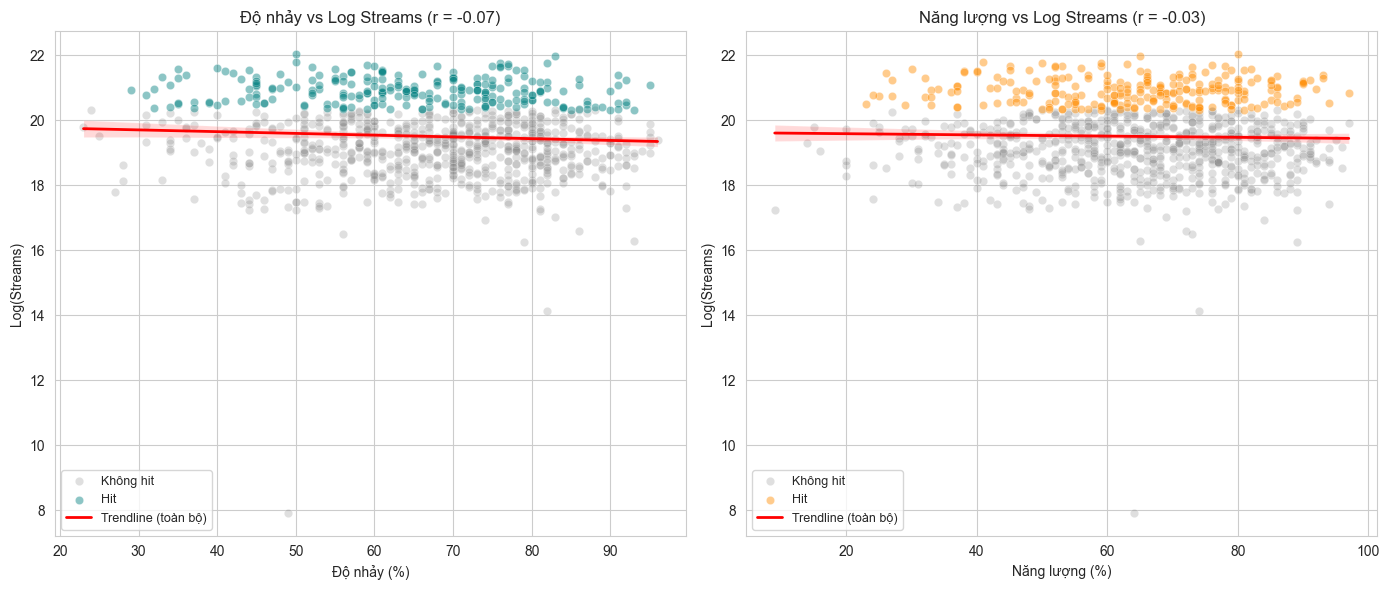

In [5]:
if 'log_streams' not in df.columns:
    df['log_streams'] = np.log1p(df['streams'])

# Nhãn Hit Status (top 25% streams) — dùng chung với mục 3b
if 'is_hit' not in df.columns:
    hit_threshold = df['streams'].quantile(0.75)
    df['is_hit'] = df['streams'] >= hit_threshold
else:
    hit_threshold = df['streams'].quantile(0.75)

df['hit_label'] = np.where(df['is_hit'], 'Hit', 'Không hit')

features = [
    ('danceability_%', 'teal', 'Độ nhảy'),
    ('energy_%', 'darkorange', 'Năng lượng'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (col, color, title_vi) in zip(axes, features):
    sns.scatterplot(
        data=df[~df['is_hit']],
        x=col,
        y='log_streams',
        alpha=0.25,
        color='gray',
        ax=ax,
        label='Không hit'
    )
    sns.scatterplot(
        data=df[df['is_hit']],
        x=col,
        y='log_streams',
        alpha=0.45,
        color=color,
        ax=ax,
        label='Hit'
    )
    sns.regplot(
        data=df,
        x=col,
        y='log_streams',
        scatter=False,
        line_kws={'color': 'red', 'linewidth': 2},
        ax=ax,
        label='Trendline (toàn bộ)'
    )
    r = df[col].corr(df['log_streams'])
    ax.set_title(f'{title_vi} vs Log Streams (r = {r:.2f})')
    ax.set_xlabel(f'{title_vi} (%)')
    ax.set_ylabel('Log(Streams)')
    ax.legend(fontsize=9)

print(f"--- Hit Status: ngưỡng Q3 = {hit_threshold / 1e6:.2f} triệu streams "
      f"({df['is_hit'].sum()} bài hit / {len(df)} bài) ---")

plt.tight_layout()
save_fig("scatter_danceability_energy_logstreams_trends")
plt.show()

### b. Phân tích nhạc lý nâng cao
* **Boxplot:** Mức độ thành công (`log_streams`) theo Tông nhạc (`key`) và Thể thức (`mode` — Trưởng/Thứ).
* **Scatter + KDE:** Mối quan hệ giữa Nhịp điệu (`bpm`) và `log_streams` (mật độ điểm).

Saving figure boxplot_key_mode_and_bpm


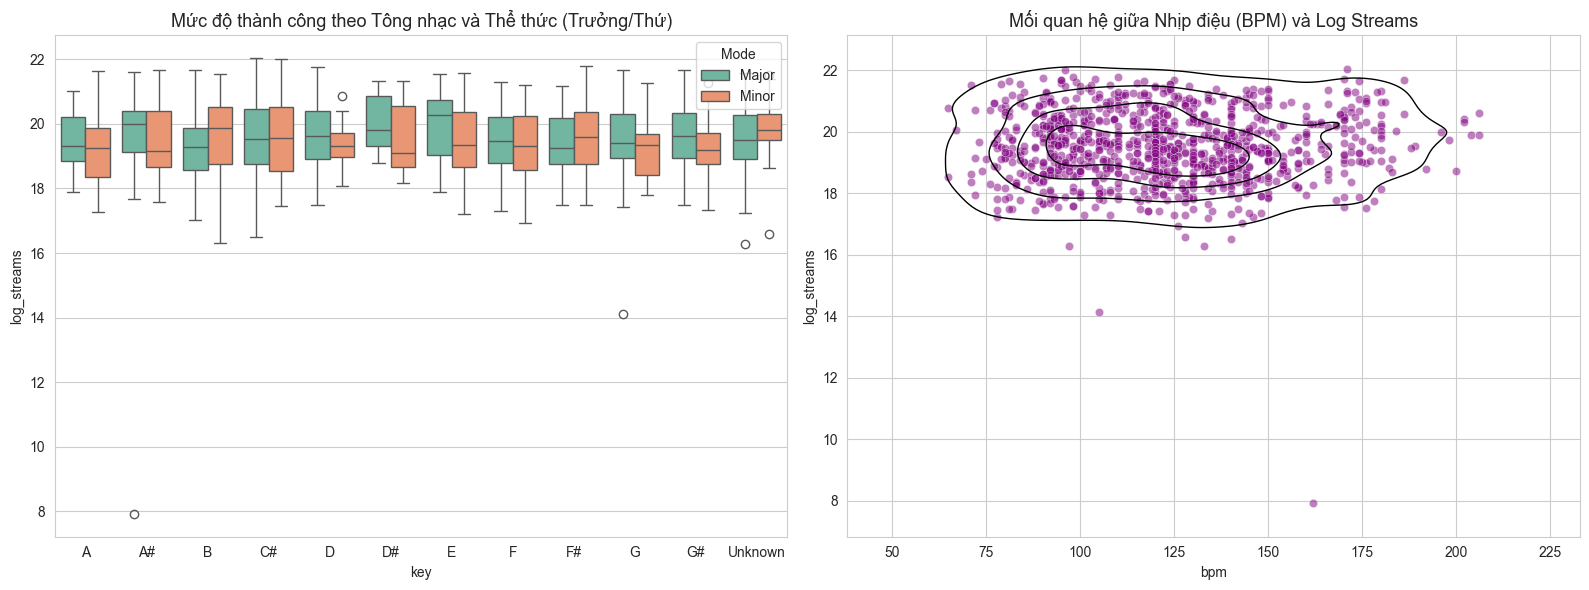

In [6]:
if 'log_streams' not in df.columns:
    df['log_streams'] = np.log1p(df['streams'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Phân tích theo Tông nhạc (Key) và Thể thức (Mode) — Boxplot
# Sắp xếp các Key theo thứ tự phổ biến hoặc bảng chữ cái để dễ nhìn
key_order = sorted(df['key'].dropna().unique())

sns.boxplot(data=df, x='key', y='log_streams', hue='mode', ax=axes[0], palette='Set2', order=key_order)
axes[0].set_title('Mức độ thành công theo Tông nhạc và Thể thức (Trưởng/Thứ)', fontsize=13)
axes[0].legend(title='Mode', loc='upper right')

# Tác động của tốc độ nhịp điệu (BPM) đến tổng lượt nghe
# Sử dụng scatter plot với mật độ điểm (hexbin hoặc scatter với alpha)
sns.scatterplot(data=df, x='bpm', y='log_streams', alpha=0.5, color='purple', ax=axes[1])
sns.kdeplot(data=df, x='bpm', y='log_streams', levels=5, color="black", linewidths=1, ax=axes[1])
axes[1].set_title('Mối quan hệ giữa Nhịp điệu (BPM) và Log Streams', fontsize=13)

plt.tight_layout()
save_fig("boxplot_key_mode_and_bpm")
plt.show()

## 3. Phân tích các yếu tố lan tỏa và phân phối (Distribution and Contextual Factors)

### a. Biểu đồ cột so sánh: Bài hát Solo vs. Bài hát Hợp tác (`artist_count`) – Xu hướng nào dễ tạo hit hơn?

--- So sánh Solo vs Hợp tác ---


,collab_type,avg_log_streams,avg_streams,song_count
0,Hợp tác (≥2 nghệ sĩ),19.29,4.275595e+08,366
1,Solo (1 nghệ sĩ),19.64,5.682117e+08,586


Saving figure barplot_solo_vs_collab


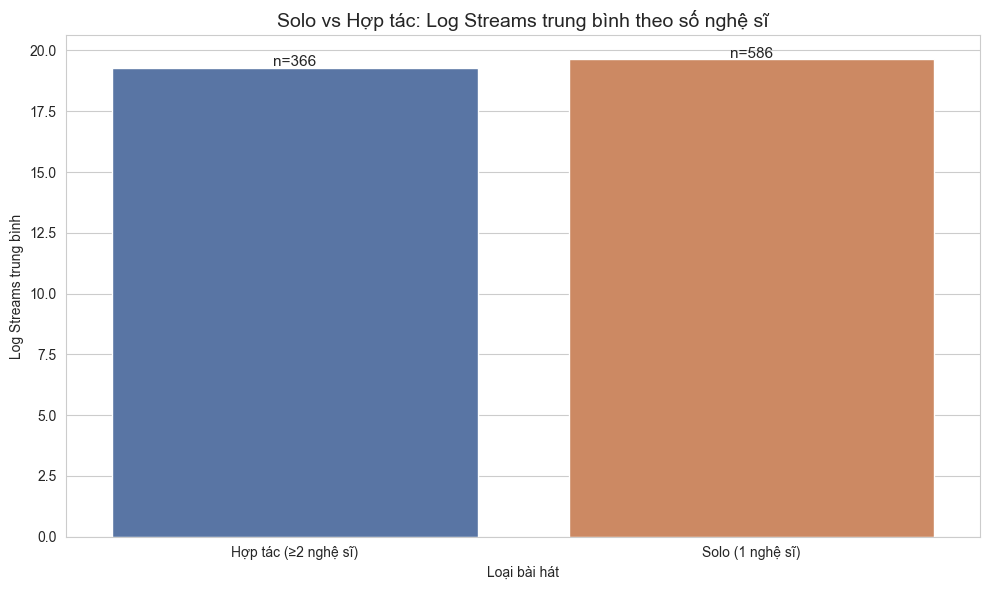

In [ ]:
# Chuẩn bị dữ liệu: phân loại Solo vs Hợp tác theo artist_count
if 'log_streams' not in df.columns:
    df['log_streams'] = np.log1p(df['streams'])

df['collab_type'] = np.where(
    df['artist_count'] == 1,
    'Solo (1 nghệ sĩ)',
    'Hợp tác (≥2 nghệ sĩ)'
)

# Tính log streams trung bình và số lượng bài hát theo từng nhóm
collab_stats = (
    df.groupby('collab_type', observed=True)
    .agg(
        avg_log_streams=('log_streams', 'mean'),
        avg_streams=('streams', 'mean'),
        song_count=('track_name', 'count')
    )
    .reset_index()
)

print("--- So sánh Solo vs Hợp tác ---")
display(collab_stats.round(2))

# Vẽ biểu đồ cột so sánh
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=collab_stats,
    x='collab_type',
    y='avg_log_streams',
    hue='collab_type',
    palette=['#4C72B0', '#DD8452'],
    legend=False
)

for i, row in collab_stats.iterrows():
    ax.text(
        i,
        row['avg_log_streams'] + 0.05,
        f"n={int(row['song_count'])}",
        ha='center',
        fontsize=11
    )

plt.title('Solo vs Hợp tác: Log Streams trung bình theo số nghệ sĩ', fontsize=14)
plt.xlabel('Loại bài hát')
plt.ylabel('Log Streams trung bình')
plt.tight_layout()
save_fig("barplot_solo_vs_collab")
plt.show()

### b. Biểu đồ đường (Line chart): Xu hướng phát hành bài hit theo các tháng trong năm (`released_month`).

--- Ngưỡng bài hit (Q3): 673.87 triệu streams ---


,hit_count,total_songs,avg_log_streams
released_month,,,
T1,62,133,19.890661
T2,9,61,19.326834
T3,26,86,19.439227
T4,11,66,19.363170
T5,22,128,19.254786
T6,15,86,19.069480
T7,15,62,19.325193
T8,12,46,19.932926
T9,20,56,19.970781


Saving figure linechart_hits_by_release_month


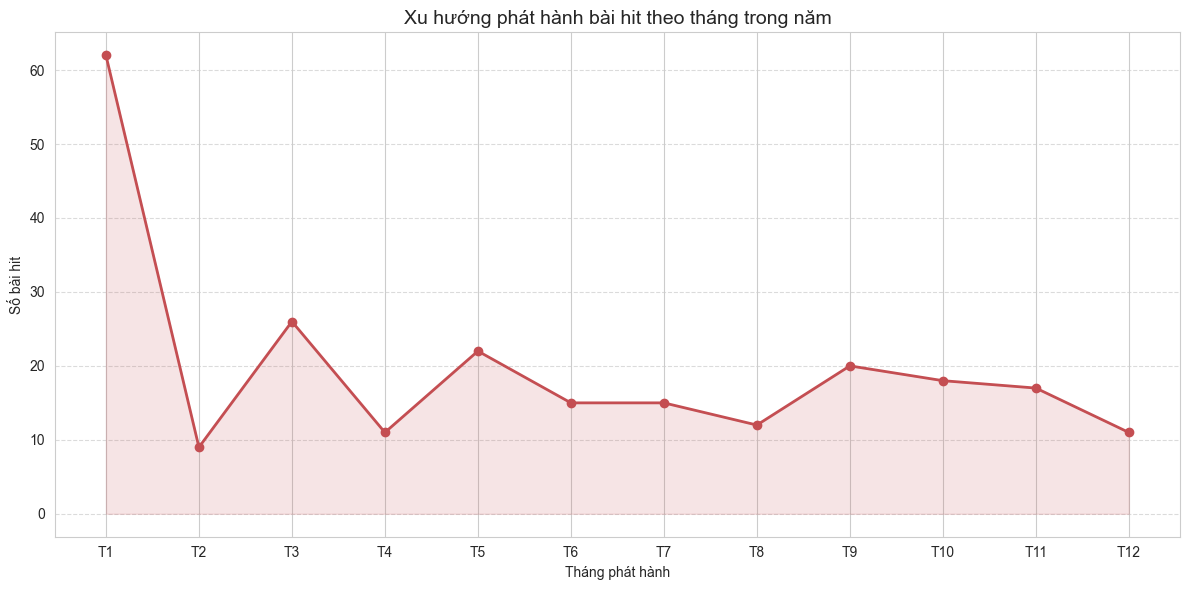

In [ ]:
# Xác định ngưỡng "bài hit" (top 25% streams) — tái dùng nếu đã tạo ở mục 2a
if 'log_streams' not in df.columns:
    df['log_streams'] = np.log1p(df['streams'])

if 'is_hit' not in df.columns:
    hit_threshold = df['streams'].quantile(0.75)
    df['is_hit'] = df['streams'] >= hit_threshold
else:
    hit_threshold = df['streams'].quantile(0.75)

month_names = {
    1: 'T1', 2: 'T2', 3: 'T3', 4: 'T4', 5: 'T5', 6: 'T6',
    7: 'T7', 8: 'T8', 9: 'T9', 10: 'T10', 11: 'T11', 12: 'T12'
}

# Thống kê số bài hit theo tháng phát hành
monthly_stats = (
    df.groupby('released_month')
    .agg(
        hit_count=('is_hit', 'sum'),
        total_songs=('track_name', 'count'),
        avg_log_streams=('log_streams', 'mean')
    )
    .reindex(range(1, 13), fill_value=0)
)
monthly_stats.index = monthly_stats.index.map(month_names)

print(f"--- Ngưỡng bài hit (Q3): {hit_threshold / 1e6:.2f} triệu streams ---")
display(monthly_stats)

# Vẽ biểu đồ đường xu hướng phát hành bài hit
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

x = range(len(monthly_stats))
plt.plot(
    x,
    monthly_stats['hit_count'],
    marker='o',
    linewidth=2,
    color='#C44E52',
    label='Số bài hit'
)
plt.fill_between(x, monthly_stats['hit_count'], alpha=0.15, color='#C44E52')

plt.title('Xu hướng phát hành bài hit theo tháng trong năm', fontsize=14)
plt.xlabel('Tháng phát hành')
plt.ylabel('Số bài hit')
plt.xticks(x, monthly_stats.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
save_fig("linechart_hits_by_release_month")
plt.show()

### c. Ma trận tương quan toàn diện (Correlation Heatmap) giữa các chỉ số âm thanh (`danceability_%`, `energy_%`, `valence_%`, `acousticness_%`) và độ phủ Playlist trên các nền tảng (Apple, Deezer, Spotify) để kiểm tra hiện tượng đa cộng tuyến.

--- Ma trận tương quan (kiểm tra đa cộng tuyến) ---


,danceability_%,energy_%,valence_%,acousticness_%,in_spotify_playlists,in_apple_playlists,in_deezer_playlists
danceability_%,1.00,0.20,0.41,-0.24,-0.11,-0.03,-0.07
energy_%,0.20,1.00,0.36,-0.58,0.03,0.05,0.06
valence_%,0.41,0.36,1.00,-0.08,-0.02,0.06,-0.01
acousticness_%,-0.24,-0.58,-0.08,1.00,-0.06,-0.06,-0.06
in_spotify_playlists,-0.11,0.03,-0.02,-0.06,1.00,0.71,0.83
in_apple_playlists,-0.03,0.05,0.06,-0.06,0.71,1.00,0.47
in_deezer_playlists,-0.07,0.06,-0.01,-0.06,0.83,0.47,1.00


Saving figure heatmap_audio_features_playlist_coverage


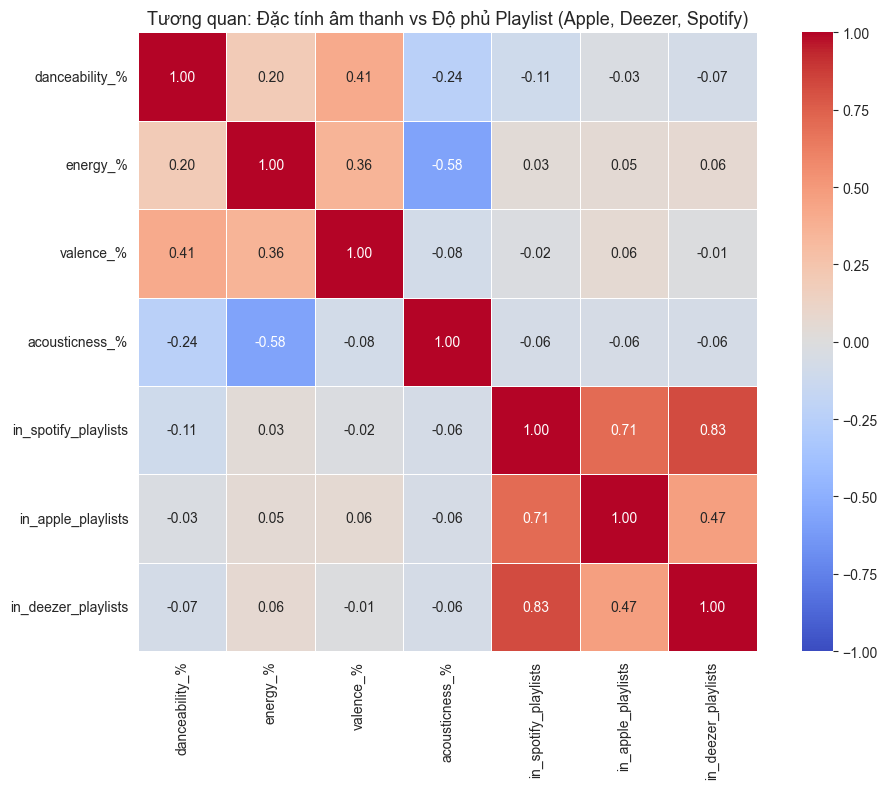


Các cặp biến có tương quan cao (|r| ≥ 0.7) — cần lưu ý đa cộng tuyến:
  in_spotify_playlists ↔ in_apple_playlists: r = 0.71
  in_spotify_playlists ↔ in_deezer_playlists: r = 0.83


In [ ]:
# Chọn các chỉ số âm thanh và độ phủ playlist trên 3 nền tảng
corr_cols = [
    'danceability_%', 'energy_%', 'valence_%', 'acousticness_%',
    'in_spotify_playlists', 'in_apple_playlists', 'in_deezer_playlists'
]

corr_matrix = df[corr_cols].corr()

print("--- Ma trận tương quan (kiểm tra đa cộng tuyến) ---")
display(corr_matrix.round(2))

# Vẽ heatmap toàn diện
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)
plt.title(
    'Tương quan: Đặc tính âm thanh vs Độ phủ Playlist (Apple, Deezer, Spotify)',
    fontsize=13
)
plt.tight_layout()
save_fig("heatmap_audio_features_playlist_coverage")
plt.show()

# Liệt kê các cặp biến có tương quan cao (|r| ≥ 0.7)
high_corr = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= 0.7:
            high_corr.append((corr_cols[i], corr_cols[j], r))

if high_corr:
    print("\nCác cặp biến có tương quan cao (|r| ≥ 0.7) — cần lưu ý đa cộng tuyến:")
    for a, b, r in high_corr:
        print(f"  {a} ↔ {b}: r = {r:.2f}")
else:
    print("\nKhông phát hiện cặp biến nào có |r| ≥ 0.7.")